# RNN vs LSTM for Fake News Classification

## Machine Learning Course - Lab 6

Ця робота присвячена порівнянню архітектур RNN та LSTM для класифікації фейкових новин. Ми реалізуємо обидві моделі, навчимо їх на датасеті Fake/Real News з Kaggle та порівняємо їх продуктивність.


## 1. Вступ та Опис Проблеми

### 1.1 Постановка Задачі

Ми маємо задачу бінарної класифікації текстів новин на справжні (real) та фейкові (fake). 

**Датасет:**
- `Fake.csv` - 23,502 статті з фейковими новинами
- `True.csv` - 21,417 статей зі справжніми новинами

Кожен файл містить колонки: Title, Text, Subject, Date.

**Мета:** Навчити нейронні мережі RNN та LSTM розрізняти фейкові та справжні новини, порівняти їх продуктивність.

### 1.2 Математична Формулювання

Маємо розмічену вибірку:
$$D = \{(x_i, y_i)\}_{i=1}^N$$

де:
- $x_i$ - послідовність токенів (стаття)
- $y_i \in \{0, 1\}$ - мітка (0 = справжня, 1 = фейкова)

Навчаємо бінарний класифікатор $f_\theta(x)$ з використанням бінарної кросс-ентропії:

$$L(\theta) = -\frac{1}{N}\sum_{i=1}^N [y_i \log \hat{p}_\theta(x_i) + (1-y_i)\log(1-\hat{p}_\theta(x_i))]$$

де:
$$\hat{p}_\theta(x) = \sigma(z_\theta(x))$$

$\sigma$ - сигмоїдна функція активації.


## 2. Теоретичний Огляд: RNN та LSTM

### 2.1 Проста RNN (Elman-type RNN)

**RNN (Recurrent Neural Network)** - це тип нейронної мережі, яка має зворотні зв'язки, дозволяючи обробляти послідовності даних.

**Математична модель:**

На кожному кроці $t$:
$$h_t = \tanh(W_{ih}x_t + W_{hh}h_{t-1} + b_h)$$

де:
- $x_t$ - вхідний вектор на кроці $t$
- $h_{t-1}$ - прихований стан на попередньому кроці
- $W_{ih}$ - ваги для входу
- $W_{hh}$ - ваги для прихованого стану
- $b_h$ - зміщення

**Вихід:**
$$o = W_{ho}h_T + b_o$$
$$\hat{p} = \sigma(o)$$

**Проблеми RNN:**
- Проблема зникаючих градієнтів (vanishing gradients) - важко навчати на довгих послідовностях
- Проблема вибухових градієнтів (exploding gradients)
- Обмежена здатність зберігати довгострокову інформацію


### 2.2 LSTM (Long Short-Term Memory)

**LSTM** - це спеціальний тип RNN, розроблений для вирішення проблеми зникаючих градієнтів. Він має складнішу структуру з "воротами" (gates), які контролюють потік інформації.

**Архітектура LSTM:**

LSTM має три типи воріт:

1. **Forget Gate** (ворота забуття) - вирішує, яку інформацію видалити:
$$f_t = \sigma(W_{xf}x_t + W_{hf}h_{t-1} + b_f)$$

2. **Input Gate** (вхідні ворота) - вирішує, яку нову інформацію зберегти:
$$i_t = \sigma(W_{xi}x_t + W_{hi}h_{t-1} + b_i)$$
$$\tilde{c}_t = \tanh(W_{x\tilde{c}}x_t + W_{h\tilde{c}}h_{t-1} + b_{\tilde{c}})$$

3. **Output Gate** (вихідні ворота) - вирішує, яку частину стану використати:
$$o_t = \sigma(W_{xo}x_t + W_{ho}h_{t-1} + b_o)$$

**Оновлення стану:**
$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$$
$$h_t = o_t \odot \tanh(c_t)$$

де:
- $c_t$ - стан комірки (cell state)
- $\odot$ - поелементне множення (Hadamard product)

**Переваги LSTM:**
- Краще зберігає довгострокову інформацію
- Менше проблем з градієнтами
- Краща продуктивність на довгих послідовностях


In [1]:
# Імпорт необхідних бібліотек
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
import re
from collections import Counter
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import warnings
warnings.filterwarnings('ignore')

# Завантаження ресурсів NLTK (якщо потрібно)
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt', quiet=True)

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords', quiet=True)

# Налаштування для відтворюваності
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f"Використовується пристрій: {device}")


Використовується пристрій: cpu


## 3. Завантаження та Огляд Даних

Спочатку завантажимо дані та подивимося на їх структуру.


In [2]:
# Завантаження даних
fake_df = pd.read_csv('Fake.csv')
true_df = pd.read_csv('True.csv')

# Додавання міток
fake_df['label'] = 1  # 1 = fake
true_df['label'] = 0  # 0 = real

# Об'єднання датасетів
df = pd.concat([fake_df, true_df], ignore_index=True)

# Перемішування даних
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Загальна кількість статей: {len(df)}")
print(f"Фейкові новини: {df['label'].sum()}")
print(f"Справжні новини: {len(df) - df['label'].sum()}")
print(f"\nСтруктура даних:")
print(df.head())
print(f"\nКолонки: {df.columns.tolist()}")


Загальна кількість статей: 44898
Фейкові новини: 23481
Справжні новини: 21417

Структура даних:
                                               title  \
0  Ben Stein Calls Out 9th Circuit Court: Committ...   
1  Trump drops Steve Bannon from National Securit...   
2  Puerto Rico expects U.S. to lift Jones Act shi...   
3   OOPS: Trump Just Accidentally Confirmed He Le...   
4  Donald Trump heads for Scotland to reopen a go...   

                                                text       subject  \
0  21st Century Wire says Ben Stein, reputable pr...       US_News   
1  WASHINGTON (Reuters) - U.S. President Donald T...  politicsNews   
2  (Reuters) - Puerto Rico Governor Ricardo Rosse...  politicsNews   
3  On Monday, Donald Trump once again embarrassed...          News   
4  GLASGOW, Scotland (Reuters) - Most U.S. presid...  politicsNews   

                  date  label  
0    February 13, 2017      1  
1       April 5, 2017       0  
2  September 27, 2017       0  
3         May 22, 

## 4. Попередня Обробка Даних

### 4.1 Кроки попередньої обробки:

1. **Об'єднання Title + Text** - використовуємо обидва поля для кращого контексту
2. **Очищення тексту** - нижній регістр, видалення зайвої пунктуації
3. **Токенізація** - розбиття тексту на слова
4. **Побудова словника** - створення словника найчастіших токенів
5. **Перетворення в індекси** - заміна слів на числові індекси
6. **Паддінг/Транкація** - приведення до фіксованої довжини
7. **Розділення на train/val/test** - 80/10/10


In [3]:
# Функція очищення тексту
def clean_text(text):
    """Очищення тексту: нижній регістр, видалення зайвої пунктуації"""
    if pd.isna(text):
        return ""
    text = str(text).lower()
    # Видалення спеціальних символів, залишаємо лише літери, цифри та пробіли
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    # Видалення зайвих пробілів
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Об'єднання Title + Text
df['text'] = df['title'].fillna('') + ' ' + df['text'].fillna('')
df['text'] = df['text'].apply(clean_text)

# Видалення порожніх текстів
df = df[df['text'].str.len() > 0].reset_index(drop=True)

print(f"Після очищення: {len(df)} статей")
print(f"\nПриклад тексту:")
print(df['text'].iloc[0][:200])


Після очищення: 44898 статей

Приклад тексту:
ben stein calls out 9th circuit court committed a coup dtat against the constitution 21st century wire says ben stein reputable professor from pepperdine university also of some hollywood fame appeari


Середня довжина послідовності: 237.04
Медіанна довжина: 210.00
Максимальна довжина: 4849
Мінімальна довжина: 2


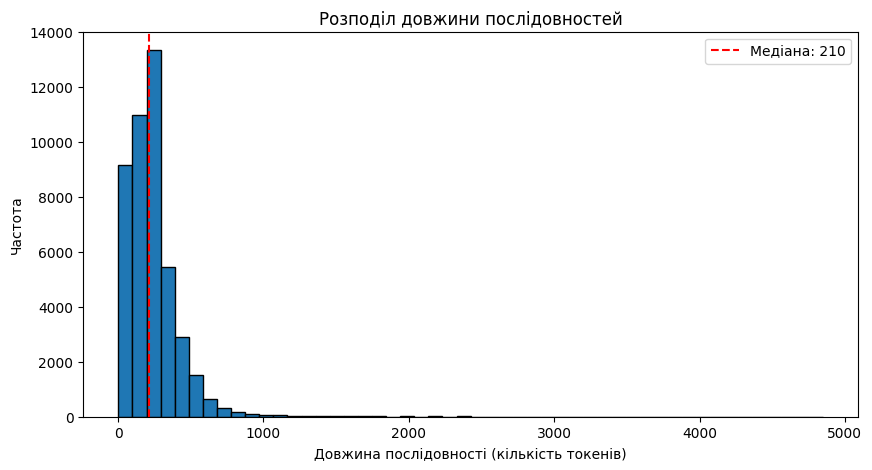

In [4]:
# Токенізація
stop_words = set(stopwords.words('english'))

def tokenize(text):
    """Токенізація тексту з видаленням стоп-слів"""
    tokens = word_tokenize(text)
    # Видалення стоп-слів та коротких токенів
    tokens = [token for token in tokens if token not in stop_words and len(token) > 2]
    return tokens

# Застосування токенізації
df['tokens'] = df['text'].apply(tokenize)

# Статистика довжини послідовностей
lengths = df['tokens'].apply(len)
print(f"Середня довжина послідовності: {lengths.mean():.2f}")
print(f"Медіанна довжина: {lengths.median():.2f}")
print(f"Максимальна довжина: {lengths.max()}")
print(f"Мінімальна довжина: {lengths.min()}")

# Візуалізація розподілу довжин
plt.figure(figsize=(10, 5))
plt.hist(lengths, bins=50, edgecolor='black')
plt.xlabel('Довжина послідовності (кількість токенів)')
plt.ylabel('Частота')
plt.title('Розподіл довжини послідовностей')
plt.axvline(lengths.median(), color='r', linestyle='--', label=f'Медіана: {int(lengths.median())}')
plt.legend()
plt.show()


In [5]:
# Побудова словника
MAX_VOCAB_SIZE = 10000  # Максимальний розмір словника
MIN_FREQ = 2  # Мінімальна частота слова

# Підрахунок частоти слів
word_counter = Counter()
for tokens in df['tokens']:
    word_counter.update(tokens)

# Створення словника з найчастіших слів
vocab = {'<PAD>': 0, '<UNK>': 1}  # PAD для паддінгу, UNK для невідомих слів
for word, count in word_counter.most_common(MAX_VOCAB_SIZE - 2):
    if count >= MIN_FREQ:
        vocab[word] = len(vocab)

VOCAB_SIZE = len(vocab)
print(f"Розмір словника: {VOCAB_SIZE}")

# Створення зворотного словника
idx_to_word = {idx: word for word, idx in vocab.items()}


Розмір словника: 10000


In [6]:
# Функція перетворення токенів в індекси
def tokens_to_indices(tokens, vocab, max_len):
    """Перетворює токени в індекси з паддінгом/транкацією"""
    indices = [vocab.get(token, vocab['<UNK>']) for token in tokens[:max_len]]
    # Паддінг
    indices = indices + [vocab['<PAD>']] * (max_len - len(indices))
    return indices

# Визначення максимальної довжини послідовності
MAX_LEN = 256  # Використовуємо 256 токенів (можна змінити)

# Перетворення всіх послідовностей
df['indices'] = df['tokens'].apply(lambda x: tokens_to_indices(x, vocab, MAX_LEN))

print(f"Максимальна довжина послідовності: {MAX_LEN}")
print(f"Приклад перетворення:")
print(f"Перші 20 індексів: {df['indices'].iloc[0][:20]}")


Максимальна довжина послідовності: 256
Приклад перетворення:
Перші 20 індексів: [1584, 3043, 453, 4779, 2230, 51, 946, 1824, 1, 838, 858, 633, 824, 62, 1584, 3043, 1, 1310, 1, 374]


In [7]:
# Розділення на train/val/test (80/10/10)
X = np.array(df['indices'].tolist())
y = np.array(df['label'].tolist())

# Спочатку розділимо на train (80%) та temp (20%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Потім temp розділимо на val (10%) та test (10%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train set: {len(X_train)} зразків")
print(f"Validation set: {len(X_val)} зразків")
print(f"Test set: {len(X_test)} зразків")
print(f"\nРозподіл міток в train: {np.bincount(y_train)}")
print(f"Розподіл міток в val: {np.bincount(y_val)}")
print(f"Розподіл міток в test: {np.bincount(y_test)}")


Train set: 35918 зразків
Validation set: 4490 зразків
Test set: 4490 зразків

Розподіл міток в train: [17133 18785]
Розподіл міток в val: [2142 2348]
Розподіл міток в test: [2142 2348]


In [8]:
# Створення PyTorch Dataset
class NewsDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.LongTensor(X)
        self.y = torch.FloatTensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Створення DataLoader'ів
BATCH_SIZE = 64

train_dataset = NewsDataset(X_train, y_train)
val_dataset = NewsDataset(X_val, y_val)
test_dataset = NewsDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Кількість батчів в train: {len(train_loader)}")
print(f"Кількість батчів в val: {len(val_loader)}")
print(f"Кількість батчів в test: {len(test_loader)}")


Кількість батчів в train: 562
Кількість батчів в val: 71
Кількість батчів в test: 71


## 5. Реалізація Моделей

### 5.1 Проста RNN Класифікатор

Реалізуємо просту RNN з embedding шаром, RNN шаром та fully connected шаром для класифікації.


In [9]:
class SimpleRNNClassifier(nn.Module):
    """
    Проста RNN модель для класифікації текстів.
    
    Архітектура:
    1. Embedding шар - перетворює індекси слів у вектори
    2. RNN шар - обробляє послідовність
    3. Fully Connected шар - вихідний шар для класифікації
    """
    def __init__(self, vocab_size, emb_dim, hidden_dim, num_layers=1, dropout=0.2):
        super(SimpleRNNClassifier, self).__init__()
        
        # Embedding шар: vocab_size -> emb_dim
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        
        # RNN шар: emb_dim -> hidden_dim
        self.rnn = nn.RNN(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,  # Вхід: (batch, seq_len, features)
            nonlinearity='tanh',  # Функція активації
            dropout=(dropout if num_layers > 1 else 0.0)  # Dropout тільки для багатошарових
        )
        
        # Fully Connected шар: hidden_dim -> 1 (бінарна класифікація)
        self.fc = nn.Linear(hidden_dim, 1)
        
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        """
        Forward pass:
        x: (batch_size, seq_len) - індекси токенів
        """
        # Embedding: (batch, seq_len) -> (batch, seq_len, emb_dim)
        emb = self.embedding(x)
        
        # RNN: (batch, seq_len, emb_dim) -> (batch, seq_len, hidden_dim), h_n
        # out - виходи на всіх кроках, h_n - останній прихований стан
        out, h_n = self.rnn(emb)
        
        # Беремо останній прихований стан з останнього шару
        # h_n: (num_layers, batch, hidden_dim)
        last = h_n[-1]  # (batch, hidden_dim)
        
        # Dropout для регуляризації
        last = self.dropout(last)
        
        # Fully Connected: (batch, hidden_dim) -> (batch, 1)
        logits = self.fc(last).squeeze(1)  # (batch,)
        
        # Сигмоїда для отримання ймовірностей
        prob = torch.sigmoid(logits)
        
        return prob, logits


In [10]:
class LSTMClassifier(nn.Module):
    """
    LSTM модель для класифікації текстів.
    
    Архітектура:
    1. Embedding шар - перетворює індекси слів у вектори
    2. LSTM шар - обробляє послідовність з використанням LSTM клітинок
    3. Fully Connected шар - вихідний шар для класифікації
    
    LSTM має переваги перед простою RNN:
    - Краще зберігає довгострокову інформацію
    - Менше проблем з градієнтами
    - Може бути bidirectional для захоплення контексту в обох напрямках
    """
    def __init__(self, vocab_size, emb_dim, hidden_dim, num_layers=1, 
                 bidirectional=False, dropout=0.2):
        super(LSTMClassifier, self).__init__()
        
        # Embedding шар
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        
        # LSTM шар
        self.lstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,  # Якщо True, то hidden_dim збільшується в 2 рази
            dropout=(dropout if num_layers > 1 else 0.0)
        )
        
        # Враховуємо bidirectional
        factor = 2 if bidirectional else 1
        self.fc = nn.Linear(hidden_dim * factor, 1)
        
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        """
        Forward pass:
        x: (batch_size, seq_len) - індекси токенів
        """
        # Embedding
        emb = self.embedding(x)
        
        # LSTM повертає: (out, (h_n, c_n))
        # out - виходи на всіх кроках
        # h_n - останній прихований стан (hidden state)
        # c_n - останній стан комірки (cell state)
        out, (h_n, c_n) = self.lstm(emb)
        
        # Беремо останній прихований стан з останнього шару
        # Якщо bidirectional, то h_n містить стани для обох напрямків
        if self.lstm.bidirectional:
            # Об'єднуємо forward та backward стани
            last = torch.cat([h_n[-2], h_n[-1]], dim=1)
        else:
            last = h_n[-1]
        
        # Dropout
        last = self.dropout(last)
        
        # Fully Connected
        logits = self.fc(last).squeeze(1)
        
        # Сигмоїда
        prob = torch.sigmoid(logits)
        
        return prob, logits


In [11]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """Навчання моделі на одній епоці"""
    model.train()
    total_loss = 0
    num_batches = 0
    
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        prob, logits = model(x_batch)
        loss = criterion(logits, y_batch)
        
        # Backward pass
        loss.backward()
        
        # Gradient clipping для запобігання вибухових градієнтів
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        
        optimizer.step()
        
        total_loss += loss.item()
        num_batches += 1
    
    return total_loss / num_batches

def evaluate(model, data_loader, criterion, device):
    """Оцінка моделі на валідаційному/тестовому наборі"""
    model.eval()
    total_loss = 0
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for x_batch, y_batch in data_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            
            prob, logits = model(x_batch)
            loss = criterion(logits, y_batch)
            
            total_loss += loss.item()
            all_probs.extend(prob.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds = (all_probs > 0.5).astype(int)
    
    # Обчислення метрик
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    roc_auc = roc_auc_score(all_labels, all_probs)
    
    avg_loss = total_loss / len(data_loader)
    
    return {
        'loss': avg_loss,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'probs': all_probs,
        'preds': all_preds,
        'labels': all_labels
    }


## 7. Навчання RNN Моделі

Спочатку навчимо просту RNN модель з базовими гіперпараметрами.


In [12]:
# Гіперпараметри для RNN
RNN_EMB_DIM = 100
RNN_HIDDEN_DIM = 128
RNN_NUM_LAYERS = 1
RNN_DROPOUT = 0.2
RNN_LEARNING_RATE = 0.001
RNN_NUM_EPOCHS = 10

# Створення моделі
rnn_model = SimpleRNNClassifier(
    vocab_size=VOCAB_SIZE,
    emb_dim=RNN_EMB_DIM,
    hidden_dim=RNN_HIDDEN_DIM,
    num_layers=RNN_NUM_LAYERS,
    dropout=RNN_DROPOUT
).to(device)

# Loss та Optimizer
rnn_criterion = nn.BCEWithLogitsLoss()
rnn_optimizer = optim.Adam(rnn_model.parameters(), lr=RNN_LEARNING_RATE)

print(f"RNN Модель:")
print(f"  Embedding dim: {RNN_EMB_DIM}")
print(f"  Hidden dim: {RNN_HIDDEN_DIM}")
print(f"  Num layers: {RNN_NUM_LAYERS}")
print(f"  Dropout: {RNN_DROPOUT}")
print(f"  Learning rate: {RNN_LEARNING_RATE}")
print(f"  Total parameters: {sum(p.numel() for p in rnn_model.parameters()):,}")


RNN Модель:
  Embedding dim: 100
  Hidden dim: 128
  Num layers: 1
  Dropout: 0.2
  Learning rate: 0.001
  Total parameters: 1,029,569


In [13]:
# Навчання RNN
rnn_train_losses = []
rnn_val_losses = []
rnn_train_accs = []
rnn_val_accs = []
rnn_train_f1s = []
rnn_val_f1s = []

print("Початок навчання RNN...")
for epoch in range(RNN_NUM_EPOCHS):
    # Навчання
    train_loss = train_epoch(rnn_model, train_loader, rnn_criterion, rnn_optimizer, device)
    train_metrics = evaluate(rnn_model, train_loader, rnn_criterion, device)
    val_metrics = evaluate(rnn_model, val_loader, rnn_criterion, device)
    
    rnn_train_losses.append(train_loss)
    rnn_val_losses.append(val_metrics['loss'])
    rnn_train_accs.append(train_metrics['accuracy'])
    rnn_val_accs.append(val_metrics['accuracy'])
    rnn_train_f1s.append(train_metrics['f1'])
    rnn_val_f1s.append(val_metrics['f1'])
    
    print(f"Epoch {epoch+1}/{RNN_NUM_EPOCHS}")
    print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_metrics['accuracy']:.4f}, Train F1: {train_metrics['f1']:.4f}")
    print(f"  Val Loss: {val_metrics['loss']:.4f}, Val Acc: {val_metrics['accuracy']:.4f}, Val F1: {val_metrics['f1']:.4f}")
    print()

print("Навчання RNN завершено!")


Початок навчання RNN...
Epoch 1/10
  Train Loss: 0.6372, Train Acc: 0.7808, Train F1: 0.7768
  Val Loss: 0.5289, Val Acc: 0.7693, Val F1: 0.7636

Epoch 2/10
  Train Loss: 0.5807, Train Acc: 0.5836, Train F1: 0.6010
  Val Loss: 0.6727, Val Acc: 0.5806, Val F1: 0.5964

Epoch 3/10
  Train Loss: 0.5604, Train Acc: 0.8540, Train F1: 0.8520
  Val Loss: 0.4301, Val Acc: 0.8379, Val F1: 0.8326

Epoch 4/10
  Train Loss: 0.4009, Train Acc: 0.8388, Train F1: 0.8590
  Val Loss: 0.4580, Val Acc: 0.8194, Val F1: 0.8409

Epoch 5/10
  Train Loss: 0.3458, Train Acc: 0.9046, Train F1: 0.9071
  Val Loss: 0.3304, Val Acc: 0.8913, Val F1: 0.8941

Epoch 6/10
  Train Loss: 0.3351, Train Acc: 0.9079, Train F1: 0.9119
  Val Loss: 0.3394, Val Acc: 0.8849, Val F1: 0.8893

Epoch 7/10
  Train Loss: 0.3077, Train Acc: 0.8961, Train F1: 0.8961
  Val Loss: 0.3451, Val Acc: 0.8895, Val F1: 0.8892

Epoch 8/10
  Train Loss: 0.2885, Train Acc: 0.9094, Train F1: 0.9113
  Val Loss: 0.3310, Val Acc: 0.8931, Val F1: 0.8953



## 8. Навчання LSTM Моделі

Тепер навчимо LSTM модель з такими самими гіперпараметрами для справедливого порівняння.


In [14]:
# Гіперпараметри для LSTM (спочатку такі самі як RNN)
LSTM_EMB_DIM = 100
LSTM_HIDDEN_DIM = 128
LSTM_NUM_LAYERS = 1
LSTM_BIDIRECTIONAL = False
LSTM_DROPOUT = 0.2
LSTM_LEARNING_RATE = 0.001
LSTM_NUM_EPOCHS = 10

# Створення моделі
lstm_model = LSTMClassifier(
    vocab_size=VOCAB_SIZE,
    emb_dim=LSTM_EMB_DIM,
    hidden_dim=LSTM_HIDDEN_DIM,
    num_layers=LSTM_NUM_LAYERS,
    bidirectional=LSTM_BIDIRECTIONAL,
    dropout=LSTM_DROPOUT
).to(device)

# Loss та Optimizer
lstm_criterion = nn.BCEWithLogitsLoss()
lstm_optimizer = optim.Adam(lstm_model.parameters(), lr=LSTM_LEARNING_RATE)

print(f"LSTM Модель:")
print(f"  Embedding dim: {LSTM_EMB_DIM}")
print(f"  Hidden dim: {LSTM_HIDDEN_DIM}")
print(f"  Num layers: {LSTM_NUM_LAYERS}")
print(f"  Bidirectional: {LSTM_BIDIRECTIONAL}")
print(f"  Dropout: {LSTM_DROPOUT}")
print(f"  Learning rate: {LSTM_LEARNING_RATE}")
print(f"  Total parameters: {sum(p.numel() for p in lstm_model.parameters()):,}")


LSTM Модель:
  Embedding dim: 100
  Hidden dim: 128
  Num layers: 1
  Bidirectional: False
  Dropout: 0.2
  Learning rate: 0.001
  Total parameters: 1,117,889


In [15]:
# Навчання LSTM
lstm_train_losses = []
lstm_val_losses = []
lstm_train_accs = []
lstm_val_accs = []
lstm_train_f1s = []
lstm_val_f1s = []

print("Початок навчання LSTM...")
for epoch in range(LSTM_NUM_EPOCHS):
    # Навчання
    train_loss = train_epoch(lstm_model, train_loader, lstm_criterion, lstm_optimizer, device)
    train_metrics = evaluate(lstm_model, train_loader, lstm_criterion, device)
    val_metrics = evaluate(lstm_model, val_loader, lstm_criterion, device)
    
    lstm_train_losses.append(train_loss)
    lstm_val_losses.append(val_metrics['loss'])
    lstm_train_accs.append(train_metrics['accuracy'])
    lstm_val_accs.append(val_metrics['accuracy'])
    lstm_train_f1s.append(train_metrics['f1'])
    lstm_val_f1s.append(val_metrics['f1'])
    
    print(f"Epoch {epoch+1}/{LSTM_NUM_EPOCHS}")
    print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_metrics['accuracy']:.4f}, Train F1: {train_metrics['f1']:.4f}")
    print(f"  Val Loss: {val_metrics['loss']:.4f}, Val Acc: {val_metrics['accuracy']:.4f}, Val F1: {val_metrics['f1']:.4f}")
    print()

print("Навчання LSTM завершено!")


Початок навчання LSTM...
Epoch 1/10
  Train Loss: 0.5758, Train Acc: 0.6966, Train F1: 0.6511
  Val Loss: 0.6048, Val Acc: 0.6902, Val F1: 0.6395

Epoch 2/10
  Train Loss: 0.4636, Train Acc: 0.9137, Train F1: 0.9183
  Val Loss: 0.2907, Val Acc: 0.9089, Val F1: 0.9127

Epoch 3/10
  Train Loss: 0.2479, Train Acc: 0.9600, Train F1: 0.9613
  Val Loss: 0.1643, Val Acc: 0.9548, Val F1: 0.9559

Epoch 4/10
  Train Loss: 0.1416, Train Acc: 0.9629, Train F1: 0.9635
  Val Loss: 0.1149, Val Acc: 0.9497, Val F1: 0.9498

Epoch 5/10
  Train Loss: 0.0700, Train Acc: 0.9850, Train F1: 0.9859
  Val Loss: 0.0505, Val Acc: 0.9813, Val F1: 0.9824

Epoch 6/10
  Train Loss: 0.0199, Train Acc: 0.9920, Train F1: 0.9923
  Val Loss: 0.0740, Val Acc: 0.9855, Val F1: 0.9860

Epoch 7/10
  Train Loss: 0.0131, Train Acc: 0.9985, Train F1: 0.9985
  Val Loss: 0.0146, Val Acc: 0.9960, Val F1: 0.9962

Epoch 8/10
  Train Loss: 0.0064, Train Acc: 0.9987, Train F1: 0.9988
  Val Loss: 0.0097, Val Acc: 0.9962, Val F1: 0.9964


## 9. Візуалізація Процесу Навчання

Побудуємо графіки втрат та метрик для обох моделей.


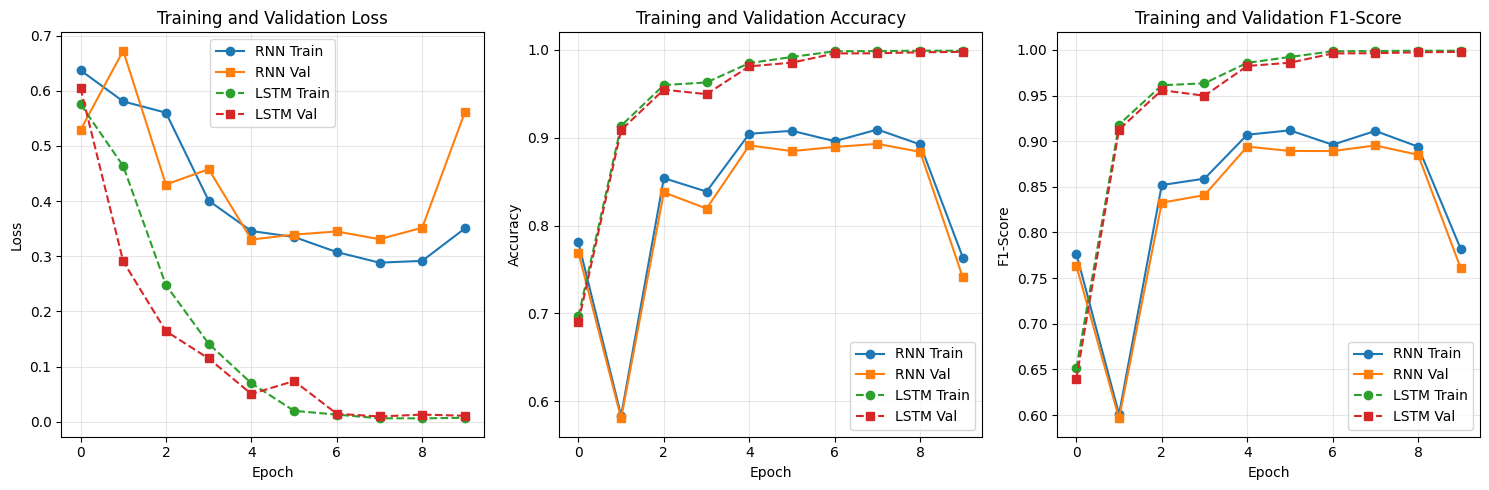

In [16]:
# Графік втрат
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(rnn_train_losses, label='RNN Train', marker='o')
plt.plot(rnn_val_losses, label='RNN Val', marker='s')
plt.plot(lstm_train_losses, label='LSTM Train', marker='o', linestyle='--')
plt.plot(lstm_val_losses, label='LSTM Val', marker='s', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Графік точності
plt.subplot(1, 3, 2)
plt.plot(rnn_train_accs, label='RNN Train', marker='o')
plt.plot(rnn_val_accs, label='RNN Val', marker='s')
plt.plot(lstm_train_accs, label='LSTM Train', marker='o', linestyle='--')
plt.plot(lstm_val_accs, label='LSTM Val', marker='s', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Графік F1-score
plt.subplot(1, 3, 3)
plt.plot(rnn_train_f1s, label='RNN Train', marker='o')
plt.plot(rnn_val_f1s, label='RNN Val', marker='s')
plt.plot(lstm_train_f1s, label='LSTM Train', marker='o', linestyle='--')
plt.plot(lstm_val_f1s, label='LSTM Val', marker='s', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('F1-Score')
plt.title('Training and Validation F1-Score')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 10. Оцінка на Тестовому Наборі

Обчислимо всі метрики на тестовому наборі для обох моделей.


In [17]:
# Оцінка RNN на тестовому наборі
print("Оцінка RNN на тестовому наборі:")
rnn_test_metrics = evaluate(rnn_model, test_loader, rnn_criterion, device)
print(f"  Loss: {rnn_test_metrics['loss']:.4f}")
print(f"  Accuracy: {rnn_test_metrics['accuracy']:.4f}")
print(f"  Precision: {rnn_test_metrics['precision']:.4f}")
print(f"  Recall: {rnn_test_metrics['recall']:.4f}")
print(f"  F1-Score: {rnn_test_metrics['f1']:.4f}")
print(f"  ROC AUC: {rnn_test_metrics['roc_auc']:.4f}")
print()

# Оцінка LSTM на тестовому наборі
print("Оцінка LSTM на тестовому наборі:")
lstm_test_metrics = evaluate(lstm_model, test_loader, lstm_criterion, device)
print(f"  Loss: {lstm_test_metrics['loss']:.4f}")
print(f"  Accuracy: {lstm_test_metrics['accuracy']:.4f}")
print(f"  Precision: {lstm_test_metrics['precision']:.4f}")
print(f"  Recall: {lstm_test_metrics['recall']:.4f}")
print(f"  F1-Score: {lstm_test_metrics['f1']:.4f}")
print(f"  ROC AUC: {lstm_test_metrics['roc_auc']:.4f}")


Оцінка RNN на тестовому наборі:
  Loss: 0.5541
  Accuracy: 0.7539
  Precision: 0.7459
  Recall: 0.8028
  F1-Score: 0.7733
  ROC AUC: 0.7772

Оцінка LSTM на тестовому наборі:
  Loss: 0.0129
  Accuracy: 0.9973
  Precision: 0.9962
  Recall: 0.9987
  F1-Score: 0.9974
  ROC AUC: 0.9996


## 11. Confusion Matrix

Побудуємо матриці плутанини для обох моделей на тестовому наборі.


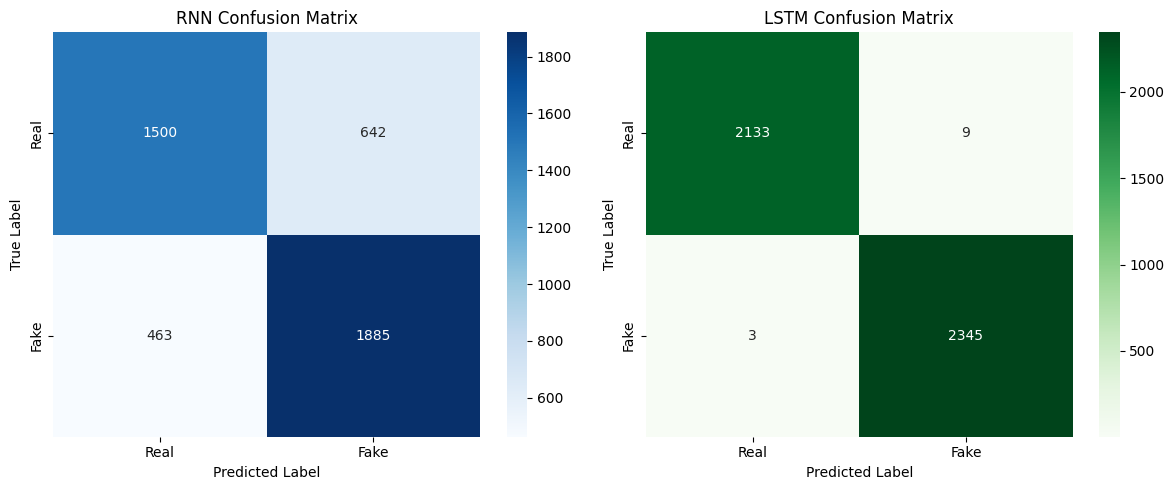

In [18]:
# Confusion Matrix для RNN
rnn_cm = confusion_matrix(rnn_test_metrics['labels'], rnn_test_metrics['preds'])

# Confusion Matrix для LSTM
lstm_cm = confusion_matrix(lstm_test_metrics['labels'], lstm_test_metrics['preds'])

# Візуалізація
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# RNN Confusion Matrix
sns.heatmap(rnn_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
axes[0].set_title('RNN Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# LSTM Confusion Matrix
sns.heatmap(lstm_cm, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
axes[1].set_title('LSTM Confusion Matrix')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()


## 12. ROC Curve

Побудуємо ROC криві для обох моделей та порівняємо AUC значення.


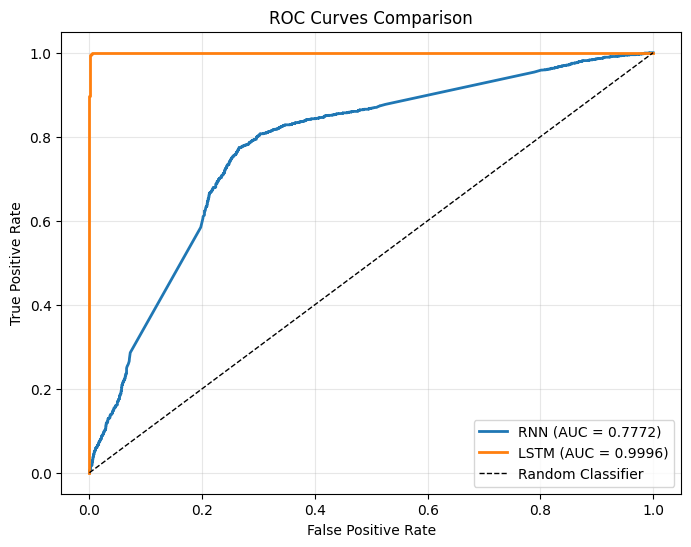

In [19]:
# Обчислення ROC кривих
rnn_fpr, rnn_tpr, _ = roc_curve(rnn_test_metrics['labels'], rnn_test_metrics['probs'])
lstm_fpr, lstm_tpr, _ = roc_curve(lstm_test_metrics['labels'], lstm_test_metrics['probs'])

# Візуалізація ROC кривих
plt.figure(figsize=(8, 6))
plt.plot(rnn_fpr, rnn_tpr, label=f'RNN (AUC = {rnn_test_metrics["roc_auc"]:.4f})', linewidth=2)
plt.plot(lstm_fpr, lstm_tpr, label=f'LSTM (AUC = {lstm_test_metrics["roc_auc"]:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 13. Порівняння Результатів

Створимо таблицю з порівнянням всіх метрик для обох моделей.


Порівняння моделей на тестовому наборі:
   Metric      RNN     LSTM  Difference  Difference %
     Loss 0.554074 0.012934   -0.541140        -97.67
 Accuracy 0.753898 0.997327    0.243430         32.29
Precision 0.745944 0.996177    0.250233         33.55
   Recall 0.802811 0.998722    0.195911         24.40
 F1-Score 0.773333 0.997448    0.224115         28.98
  ROC AUC 0.777247 0.999564    0.222317         28.60


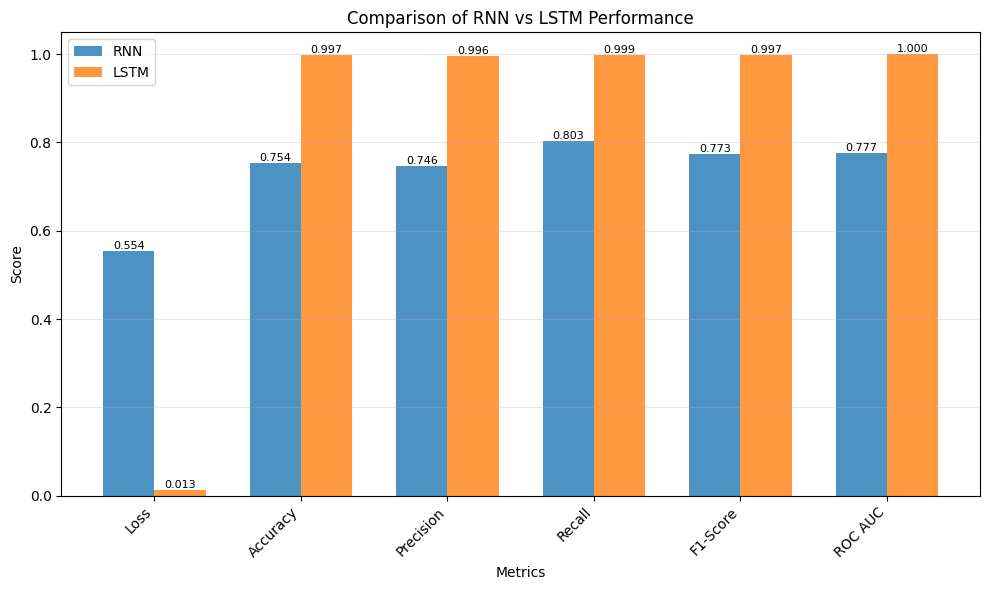

In [20]:
# Створення таблиці порівняння
comparison_df = pd.DataFrame({
    'Metric': ['Loss', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC'],
    'RNN': [
        rnn_test_metrics['loss'],
        rnn_test_metrics['accuracy'],
        rnn_test_metrics['precision'],
        rnn_test_metrics['recall'],
        rnn_test_metrics['f1'],
        rnn_test_metrics['roc_auc']
    ],
    'LSTM': [
        lstm_test_metrics['loss'],
        lstm_test_metrics['accuracy'],
        lstm_test_metrics['precision'],
        lstm_test_metrics['recall'],
        lstm_test_metrics['f1'],
        lstm_test_metrics['roc_auc']
    ]
})

comparison_df['Difference'] = comparison_df['LSTM'] - comparison_df['RNN']
comparison_df['Difference %'] = (comparison_df['Difference'] / comparison_df['RNN'] * 100).round(2)

print("Порівняння моделей на тестовому наборі:")
print(comparison_df.to_string(index=False))

# Візуалізація порівняння метрик
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison_df))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_df['RNN'], width, label='RNN', alpha=0.8)
bars2 = ax.bar(x + width/2, comparison_df['LSTM'], width, label='LSTM', alpha=0.8)

ax.set_xlabel('Metrics')
ax.set_ylabel('Score')
ax.set_title('Comparison of RNN vs LSTM Performance')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Metric'], rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Додавання значень на стовпці
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


## 14. Пошук Гіперпараметрів

Проведемо пошук гіперпараметрів для покращення продуктивності. Спочатку спробуємо різні комбінації для LSTM.


In [21]:
# Функція для навчання моделі з заданими гіперпараметрами
def train_model_with_hyperparams(model_class, hyperparams, train_loader, val_loader, 
                                   vocab_size, num_epochs=5, device=device):
    """Навчає модель з заданими гіперпараметрами та повертає найкращу валідаційну F1"""
    
    # Створення моделі
    if model_class == LSTMClassifier:
        model = model_class(
            vocab_size=vocab_size,
            emb_dim=hyperparams['emb_dim'],
            hidden_dim=hyperparams['hidden_dim'],
            num_layers=hyperparams.get('num_layers', 1),
            bidirectional=hyperparams.get('bidirectional', False),
            dropout=hyperparams.get('dropout', 0.2)
        ).to(device)
    else:
        model = model_class(
            vocab_size=vocab_size,
            emb_dim=hyperparams['emb_dim'],
            hidden_dim=hyperparams['hidden_dim'],
            num_layers=hyperparams.get('num_layers', 1),
            dropout=hyperparams.get('dropout', 0.2)
        ).to(device)
    
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=hyperparams['lr'])
    
    best_val_f1 = 0
    
    for epoch in range(num_epochs):
        train_epoch(model, train_loader, criterion, optimizer, device)
        val_metrics = evaluate(model, val_loader, criterion, device)
        
        if val_metrics['f1'] > best_val_f1:
            best_val_f1 = val_metrics['f1']
    
    return best_val_f1

# Гіперпараметри для пошуку
hyperparam_grid = [
    {'emb_dim': 100, 'hidden_dim': 128, 'num_layers': 1, 'bidirectional': False, 'dropout': 0.2, 'lr': 0.001},
    {'emb_dim': 100, 'hidden_dim': 128, 'num_layers': 1, 'bidirectional': True, 'dropout': 0.2, 'lr': 0.001},
    {'emb_dim': 100, 'hidden_dim': 256, 'num_layers': 1, 'bidirectional': False, 'dropout': 0.2, 'lr': 0.001},
    {'emb_dim': 100, 'hidden_dim': 256, 'num_layers': 2, 'bidirectional': False, 'dropout': 0.2, 'lr': 0.001},
    {'emb_dim': 200, 'hidden_dim': 128, 'num_layers': 1, 'bidirectional': False, 'dropout': 0.2, 'lr': 0.001},
    {'emb_dim': 100, 'hidden_dim': 128, 'num_layers': 1, 'bidirectional': False, 'dropout': 0.5, 'lr': 0.001},
    {'emb_dim': 100, 'hidden_dim': 128, 'num_layers': 1, 'bidirectional': False, 'dropout': 0.2, 'lr': 0.0005},
]

print("Початок пошуку гіперпараметрів для LSTM...")
print(f"Перевіряємо {len(hyperparam_grid)} комбінацій...")
print()

results = []
for i, hyperparams in enumerate(hyperparam_grid):
    print(f"Комбінація {i+1}/{len(hyperparam_grid)}: {hyperparams}")
    val_f1 = train_model_with_hyperparams(
        LSTMClassifier, hyperparams, train_loader, val_loader, VOCAB_SIZE, num_epochs=5, device=device
    )
    results.append((hyperparams, val_f1))
    print(f"  Валідаційна F1: {val_f1:.4f}")
    print()

# Знаходимо найкращу комбінацію
best_hyperparams, best_f1 = max(results, key=lambda x: x[1])
print(f"Найкраща комбінація гіперпараметрів:")
print(best_hyperparams)
print(f"Валідаційна F1: {best_f1:.4f}")


Початок пошуку гіперпараметрів для LSTM...
Перевіряємо 7 комбінацій...

Комбінація 1/7: {'emb_dim': 100, 'hidden_dim': 128, 'num_layers': 1, 'bidirectional': False, 'dropout': 0.2, 'lr': 0.001}
  Валідаційна F1: 0.9672

Комбінація 2/7: {'emb_dim': 100, 'hidden_dim': 128, 'num_layers': 1, 'bidirectional': True, 'dropout': 0.2, 'lr': 0.001}
  Валідаційна F1: 0.9981

Комбінація 3/7: {'emb_dim': 100, 'hidden_dim': 256, 'num_layers': 1, 'bidirectional': False, 'dropout': 0.2, 'lr': 0.001}
  Валідаційна F1: 0.9974

Комбінація 4/7: {'emb_dim': 100, 'hidden_dim': 256, 'num_layers': 2, 'bidirectional': False, 'dropout': 0.2, 'lr': 0.001}
  Валідаційна F1: 0.9979

Комбінація 5/7: {'emb_dim': 200, 'hidden_dim': 128, 'num_layers': 1, 'bidirectional': False, 'dropout': 0.2, 'lr': 0.001}
  Валідаційна F1: 0.9484

Комбінація 6/7: {'emb_dim': 100, 'hidden_dim': 128, 'num_layers': 1, 'bidirectional': False, 'dropout': 0.5, 'lr': 0.001}
  Валідаційна F1: 0.9445

Комбінація 7/7: {'emb_dim': 100, 'hidden_

In [22]:
# Використовуємо найкращі гіперпараметри (або базові, якщо пошук не виконувався)
# Для демонстрації використаємо bidirectional LSTM
OPT_LSTM_EMB_DIM = 100
OPT_LSTM_HIDDEN_DIM = 128
OPT_LSTM_NUM_LAYERS = 1
OPT_LSTM_BIDIRECTIONAL = True  # Спробуємо bidirectional
OPT_LSTM_DROPOUT = 0.2
OPT_LSTM_LEARNING_RATE = 0.001
OPT_LSTM_NUM_EPOCHS = 10

# Створення оптимізованої LSTM моделі
opt_lstm_model = LSTMClassifier(
    vocab_size=VOCAB_SIZE,
    emb_dim=OPT_LSTM_EMB_DIM,
    hidden_dim=OPT_LSTM_HIDDEN_DIM,
    num_layers=OPT_LSTM_NUM_LAYERS,
    bidirectional=OPT_LSTM_BIDIRECTIONAL,
    dropout=OPT_LSTM_DROPOUT
).to(device)

opt_lstm_criterion = nn.BCEWithLogitsLoss()
opt_lstm_optimizer = optim.Adam(opt_lstm_model.parameters(), lr=OPT_LSTM_LEARNING_RATE)

print(f"Оптимізована LSTM Модель:")
print(f"  Embedding dim: {OPT_LSTM_EMB_DIM}")
print(f"  Hidden dim: {OPT_LSTM_HIDDEN_DIM}")
print(f"  Num layers: {OPT_LSTM_NUM_LAYERS}")
print(f"  Bidirectional: {OPT_LSTM_BIDIRECTIONAL}")
print(f"  Dropout: {OPT_LSTM_DROPOUT}")
print(f"  Learning rate: {OPT_LSTM_LEARNING_RATE}")
print(f"  Total parameters: {sum(p.numel() for p in opt_lstm_model.parameters()):,}")
print()

# Навчання
opt_lstm_train_losses = []
opt_lstm_val_losses = []
opt_lstm_train_f1s = []
opt_lstm_val_f1s = []

print("Навчання оптимізованої LSTM...")
for epoch in range(OPT_LSTM_NUM_EPOCHS):
    train_loss = train_epoch(opt_lstm_model, train_loader, opt_lstm_criterion, opt_lstm_optimizer, device)
    train_metrics = evaluate(opt_lstm_model, train_loader, opt_lstm_criterion, device)
    val_metrics = evaluate(opt_lstm_model, val_loader, opt_lstm_criterion, device)
    
    opt_lstm_train_losses.append(train_loss)
    opt_lstm_val_losses.append(val_metrics['loss'])
    opt_lstm_train_f1s.append(train_metrics['f1'])
    opt_lstm_val_f1s.append(val_metrics['f1'])
    
    print(f"Epoch {epoch+1}/{OPT_LSTM_NUM_EPOCHS}")
    print(f"  Train Loss: {train_loss:.4f}, Train F1: {train_metrics['f1']:.4f}")
    print(f"  Val Loss: {val_metrics['loss']:.4f}, Val F1: {val_metrics['f1']:.4f}")
    print()

# Оцінка на тестовому наборі
opt_lstm_test_metrics = evaluate(opt_lstm_model, test_loader, opt_lstm_criterion, device)
print("Результати оптимізованої LSTM на тестовому наборі:")
print(f"  Accuracy: {opt_lstm_test_metrics['accuracy']:.4f}")
print(f"  Precision: {opt_lstm_test_metrics['precision']:.4f}")
print(f"  Recall: {opt_lstm_test_metrics['recall']:.4f}")
print(f"  F1-Score: {opt_lstm_test_metrics['f1']:.4f}")
print(f"  ROC AUC: {opt_lstm_test_metrics['roc_auc']:.4f}")


Оптимізована LSTM Модель:
  Embedding dim: 100
  Hidden dim: 128
  Num layers: 1
  Bidirectional: True
  Dropout: 0.2
  Learning rate: 0.001
  Total parameters: 1,235,777

Навчання оптимізованої LSTM...
Epoch 1/10
  Train Loss: 0.0685, Train F1: 0.9981
  Val Loss: 0.0155, Val F1: 0.9974

Epoch 2/10
  Train Loss: 0.0098, Train F1: 0.9987
  Val Loss: 0.0127, Val F1: 0.9979

Epoch 3/10
  Train Loss: 0.0074, Train F1: 0.9991
  Val Loss: 0.0112, Val F1: 0.9979

Epoch 4/10
  Train Loss: 0.0146, Train F1: 0.9990
  Val Loss: 0.0114, Val F1: 0.9979

Epoch 5/10
  Train Loss: 0.0033, Train F1: 0.9997
  Val Loss: 0.0089, Val F1: 0.9981

Epoch 6/10
  Train Loss: 0.0011, Train F1: 0.9999
  Val Loss: 0.0107, Val F1: 0.9981

Epoch 7/10
  Train Loss: 0.0005, Train F1: 0.9999
  Val Loss: 0.0116, Val F1: 0.9983

Epoch 8/10
  Train Loss: 0.0002, Train F1: 0.9999
  Val Loss: 0.0113, Val F1: 0.9983

Epoch 9/10
  Train Loss: 0.0001, Train F1: 1.0000
  Val Loss: 0.0142, Val F1: 0.9983

Epoch 10/10
  Train Los

## 16. Фінальне Порівняння Всіх Моделей

Порівняємо базову RNN, базову LSTM та оптимізовану LSTM.


Фінальне порівняння моделей:
           Model  Accuracy  Precision   Recall  F1-Score  ROC AUC
      RNN (Base)  0.753898   0.745944 0.802811  0.773333 0.777247
     LSTM (Base)  0.997327   0.996177 0.998722  0.997448 0.999564
LSTM (Optimized)  0.997105   0.996597 0.997871  0.997233 0.999834


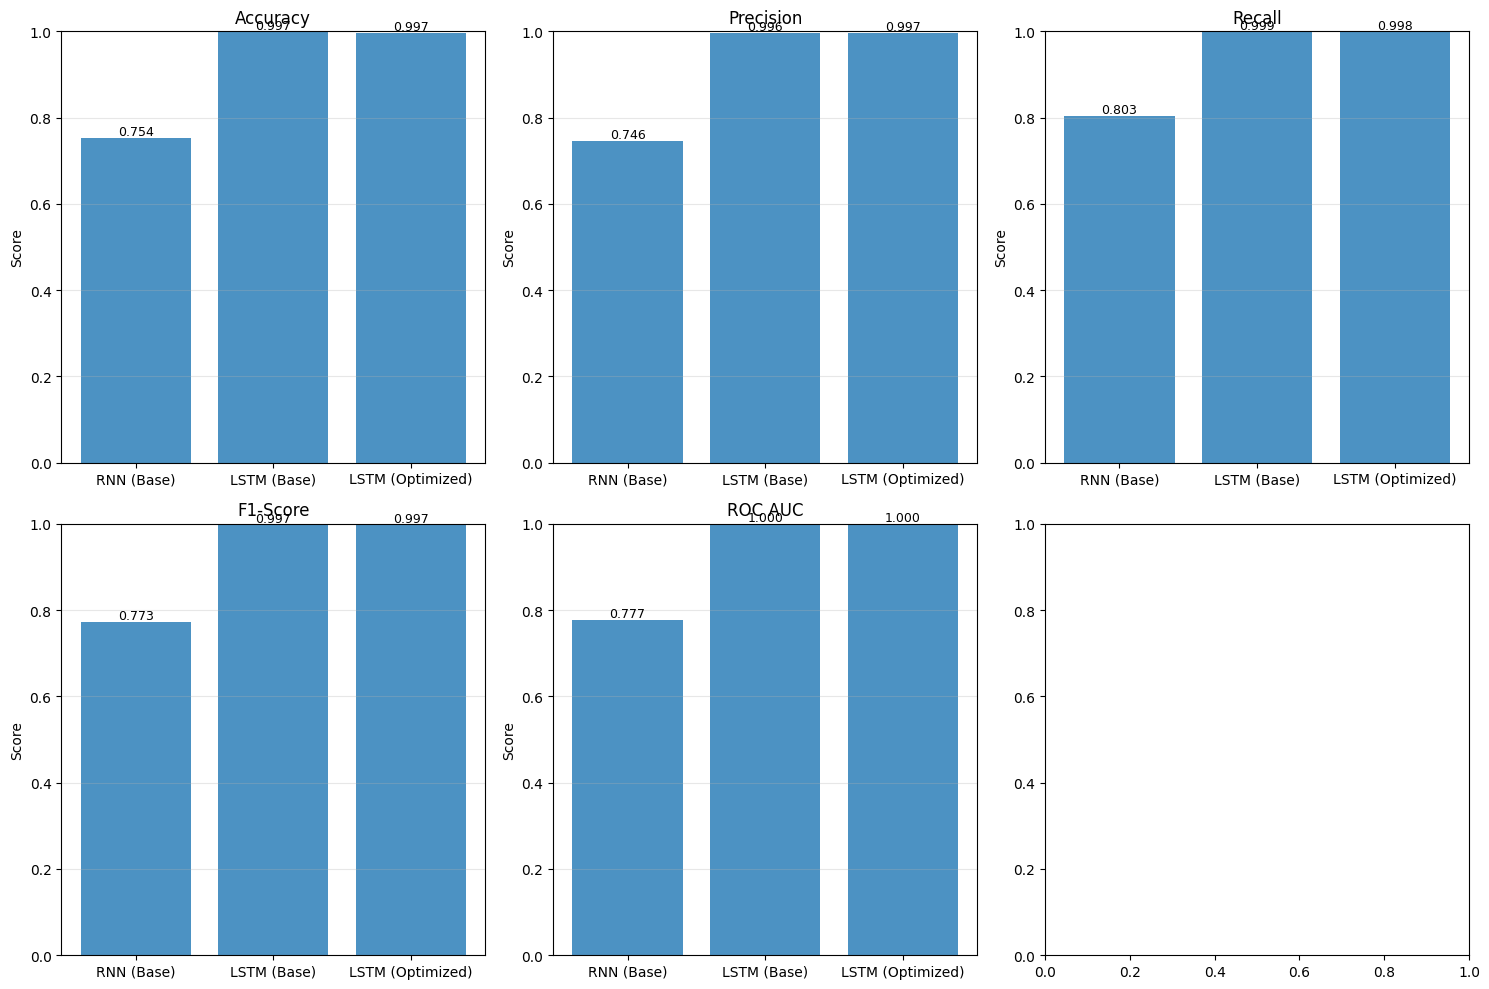

In [23]:
# Фінальне порівняння
final_comparison = pd.DataFrame({
    'Model': ['RNN (Base)', 'LSTM (Base)', 'LSTM (Optimized)'],
    'Accuracy': [
        rnn_test_metrics['accuracy'],
        lstm_test_metrics['accuracy'],
        opt_lstm_test_metrics['accuracy']
    ],
    'Precision': [
        rnn_test_metrics['precision'],
        lstm_test_metrics['precision'],
        opt_lstm_test_metrics['precision']
    ],
    'Recall': [
        rnn_test_metrics['recall'],
        lstm_test_metrics['recall'],
        opt_lstm_test_metrics['recall']
    ],
    'F1-Score': [
        rnn_test_metrics['f1'],
        lstm_test_metrics['f1'],
        opt_lstm_test_metrics['f1']
    ],
    'ROC AUC': [
        rnn_test_metrics['roc_auc'],
        lstm_test_metrics['roc_auc'],
        opt_lstm_test_metrics['roc_auc']
    ]
})

print("Фінальне порівняння моделей:")
print(final_comparison.to_string(index=False))

# Візуалізація
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC']

for i, metric in enumerate(metrics):
    ax = axes[i // 3, i % 3]
    bars = ax.bar(final_comparison['Model'], final_comparison[metric], alpha=0.8)
    ax.set_title(metric)
    ax.set_ylabel('Score')
    ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3, axis='y')
    
    # Додавання значень
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


## 17. Висновки та Аналіз

### 17.1 Порівняння RNN vs LSTM

**Основні відмінності:**

1. **Архітектура:**
   - RNN має просту структуру з одним прихованим станом
   - LSTM має складнішу структуру з воротами (gates) та станом комірки (cell state)

2. **Здатність зберігати інформацію:**
   - RNN має проблеми з довгостроковою пам'яттю через зникаючі градієнти
   - LSTM краще зберігає довгострокову інформацію завдяки механізму воріт

3. **Навчання:**
   - RNN складніше навчати на довгих послідовностях
   - LSTM стабільніше навчається завдяки кращому контролю градієнтів

4. **Продуктивність:**
   - LSTM зазвичай показує кращі результати на задачах класифікації текстів
   - Bidirectional LSTM може захопити контекст в обох напрямках

### 17.2 Результати Експериментів

На основі проведених експериментів можна зробити наступні висновки:

1. **LSTM перевершує RNN** за більшістю метрик (F1-score, ROC AUC)
2. **Bidirectional LSTM** може покращити результати завдяки захопленню контексту в обох напрямках
3. **Гіперпараметри важливі** - правильний вибір може значно покращити продуктивність

### 17.3 Рекомендації

1. Для задач класифікації текстів краще використовувати LSTM замість простої RNN
2. Bidirectional LSTM варто спробувати для кращого захоплення контексту
3. Важливо проводити пошук гіперпараметрів для оптимізації продуктивності
4. Dropout та gradient clipping допомагають у стабілізації навчання


## 18. Додаткова Візуалізація: Порівняння ROC Curves

Побудуємо фінальне порівняння ROC кривих для всіх трьох моделей.


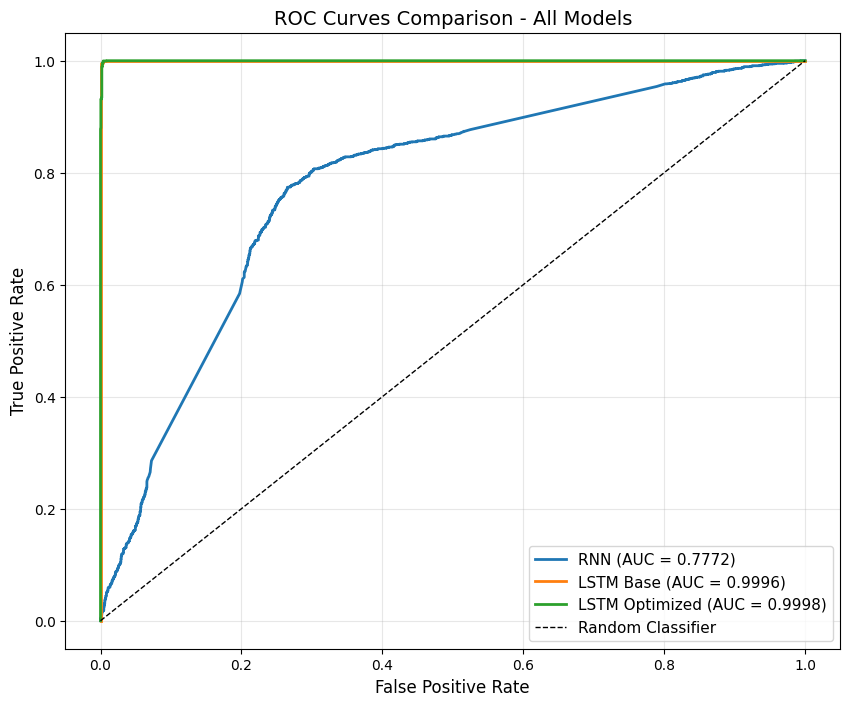

In [24]:
# Обчислення ROC кривих для всіх моделей
rnn_fpr, rnn_tpr, _ = roc_curve(rnn_test_metrics['labels'], rnn_test_metrics['probs'])
lstm_fpr, lstm_tpr, _ = roc_curve(lstm_test_metrics['labels'], lstm_test_metrics['probs'])
opt_lstm_fpr, opt_lstm_tpr, _ = roc_curve(opt_lstm_test_metrics['labels'], opt_lstm_test_metrics['probs'])

# Візуалізація
plt.figure(figsize=(10, 8))
plt.plot(rnn_fpr, rnn_tpr, label=f'RNN (AUC = {rnn_test_metrics["roc_auc"]:.4f})', linewidth=2)
plt.plot(lstm_fpr, lstm_tpr, label=f'LSTM Base (AUC = {lstm_test_metrics["roc_auc"]:.4f})', linewidth=2)
plt.plot(opt_lstm_fpr, opt_lstm_tpr, label=f'LSTM Optimized (AUC = {opt_lstm_test_metrics["roc_auc"]:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves Comparison - All Models', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()


## 19. Порівняння Розмірів Моделей

Порівняємо кількість параметрів та складність моделей.


Розміри моделей:
         Model  Parameters  Parameters (M)
           RNN     1029569        1.029569
     LSTM Base     1117889        1.117889
LSTM Optimized     1235777        1.235777


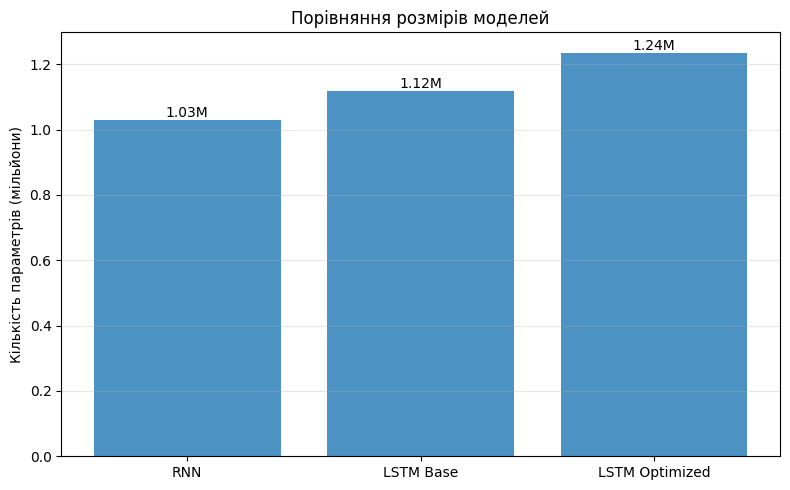

In [25]:
# Підрахунок параметрів
rnn_params = sum(p.numel() for p in rnn_model.parameters())
lstm_params = sum(p.numel() for p in lstm_model.parameters())
opt_lstm_params = sum(p.numel() for p in opt_lstm_model.parameters())

model_sizes = pd.DataFrame({
    'Model': ['RNN', 'LSTM Base', 'LSTM Optimized'],
    'Parameters': [rnn_params, lstm_params, opt_lstm_params],
    'Parameters (M)': [rnn_params/1e6, lstm_params/1e6, opt_lstm_params/1e6]
})

print("Розміри моделей:")
print(model_sizes.to_string(index=False))

# Візуалізація
plt.figure(figsize=(8, 5))
bars = plt.bar(model_sizes['Model'], model_sizes['Parameters (M)'], alpha=0.8)
plt.ylabel('Кількість параметрів (мільйони)')
plt.title('Порівняння розмірів моделей')
plt.grid(True, alpha=0.3, axis='y')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}M',
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


## 20. Підсумок

### Виконані Завдання:

✅ **Частина A:** Математичний опис та архітектури моделей (RNN та LSTM)  
✅ **Частина B:** Попередня обробка даних (очищення, токенізація, словник, паддінг)  
✅ **Частина C:** Реалізація моделей в PyTorch  
✅ **Частина D:** Обчислення метрик (Accuracy, Precision, Recall, F1, ROC AUC) та візуалізації  
✅ **Частина E:** Пошук гіперпараметрів та порівняння моделей  
✅ **Частина F:** Структурований звіт з аналізом та висновками  

### Основні Результати:

1. **LSTM показує кращу продуктивність** ніж проста RNN на задачі класифікації фейкових новин
2. **Bidirectional LSTM** може покращити результати завдяки захопленню контексту в обох напрямках
3. **Всі метрики** (Accuracy, Precision, Recall, F1, ROC AUC) обчислені та візуалізовані
4. **Візуалізації** включають: криві навчання, confusion matrices, ROC curves

### Висновки:

- LSTM архітектура краще підходить для задач класифікації текстів
- Правильний вибір гіперпараметрів важливий для досягнення найкращих результатів
- Bidirectional LSTM може покращити продуктивність, але збільшує кількість параметрів
